In [1]:
%matplotlib inline

In [2]:
import os
import glob
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import time

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Config

In [16]:
CFG = {
    "dataset_dir": "/content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_4_kpconv/dataset",
    "output_dir": "/content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_4_kpconv/output",

    "num_points": 4096,
    "num_classes": 14,

    "batch_size": 12,
    "epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "scheduler_step": 15,
    "scheduler_gamma": 0.5,

    # KPConv
    "num_kernel_points": 15,
    "k": 24,
    "sigma_ratio": 0.5,
    "dims": [64, 128, 256, 512],
    "npoints": [4096, 1024, 256, 64],
    "dropout": 0.5,

    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    "seed": 42,
    "num_workers": 2,
}


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(CFG["seed"])
os.makedirs(CFG["output_dir"], exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## PLY Loader

In [17]:
def load_ply(filepath):
    with open(filepath, "r") as f:
        line = f.readline().strip()
        assert line == "ply", f"Not a PLY file: {filepath}"
        num_vertices = None
        while True:
            line = f.readline().strip()
            if line.startswith("element vertex"):
                num_vertices = int(line.split()[-1])
            if line == "end_header":
                break
        assert num_vertices is not None
        points = np.empty((num_vertices, 3), dtype=np.float32)
        labels = np.empty(num_vertices, dtype=np.int64)
        for i in range(num_vertices):
            parts = f.readline().strip().split()
            points[i, 0] = float(parts[0])
            points[i, 1] = float(parts[1])
            points[i, 2] = float(parts[2])
            labels[i] = int(parts[3])
    return points, labels

## Data investigation

In [18]:
def investigate_dataset(file_list):
    global_counts = Counter()
    point_counts = []
    for fp in file_list:
        _, labels = load_ply(fp)
        point_counts.append(len(labels))
        for lbl in labels:
            global_counts[lbl] += 1

    classes = sorted(global_counts.keys())
    num_classes = len(classes)
    total_points = sum(global_counts.values())

    print("=" * 60)
    print("DATASET INVESTIGATION")
    print("=" * 60)
    print(f"Files           : {len(file_list)}")
    print(f"Points/file     : min={min(point_counts)}, "
          f"max={max(point_counts)}, mean={np.mean(point_counts):.0f}")
    print(f"Classes found   : {classes}")
    print(f"Num classes     : {num_classes}")
    print(f"Total points    : {total_points}")
    print("-" * 60)
    for c in classes:
        print(f"  Class {c:>3}: {global_counts[c]:>12,}  "
              f"({global_counts[c] / total_points:.4f})")
    print("=" * 60)

    counts_arr = np.array([global_counts[c] for c in classes], dtype=np.float64)
    inv_freq = total_points / (num_classes * counts_arr)
    inv_freq = inv_freq / np.median(inv_freq)
    inv_freq = np.clip(inv_freq, 0.5, 5.0)
    print(f"CE weights: {np.round(inv_freq, 4).tolist()}")

    return num_classes, classes, inv_freq

## Data preparation

In [19]:
class PointCloudDataset(Dataset):
    def __init__(self, file_list, num_points=4096, augment=False):
        super().__init__()
        self.file_list = file_list
        self.num_points = num_points
        self.augment = augment
        self.data = []
        for fp in file_list:
            pts, lbl = load_ply(fp)
            self.data.append((pts, lbl))

    def __len__(self):
        return len(self.data)

    def _normalize(self, points):
        centroid = points.mean(axis=0)
        points = points - centroid
        max_dist = np.max(np.linalg.norm(points, axis=1))
        if max_dist > 0:
            points = points / max_dist
        return points

    @staticmethod
    def _apply_augment_transforms(points):
        angle_y = np.random.uniform(0, 2 * np.pi)
        angle_x = np.random.uniform(-np.pi / 18, np.pi / 18)
        angle_z = np.random.uniform(-np.pi / 18, np.pi / 18)
        Ry = np.array([[np.cos(angle_y), 0, np.sin(angle_y)],
                        [0, 1, 0],
                        [-np.sin(angle_y), 0, np.cos(angle_y)]],
                       dtype=np.float32)
        Rx = np.array([[1, 0, 0],
                        [0, np.cos(angle_x), -np.sin(angle_x)],
                        [0, np.sin(angle_x), np.cos(angle_x)]],
                       dtype=np.float32)
        Rz = np.array([[np.cos(angle_z), -np.sin(angle_z), 0],
                        [np.sin(angle_z), np.cos(angle_z), 0],
                        [0, 0, 1]], dtype=np.float32)
        R = Rz @ Ry @ Rx
        points = points @ R.T
        scale = np.random.uniform(0.8, 1.2)
        points = points * scale
        jitter = np.clip(
            np.random.normal(0, 0.01, size=points.shape).astype(np.float32),
            -0.05, 0.05)
        points = points + jitter
        return points

    def __getitem__(self, idx):
        points, labels = self.data[idx]
        points, labels = points.copy(), labels.copy()
        points = self._normalize(points)

        N = len(points)
        if N >= self.num_points:
            choice = np.random.choice(N, self.num_points, replace=False)
        else:
            choice = np.random.choice(N, self.num_points, replace=True)
        points, labels = points[choice], labels[choice]

        if self.augment:
            perm = np.random.permutation(self.num_points)
            points, labels = points[perm], labels[perm]
            points = self._apply_augment_transforms(points)

        # (N, 3) — channels-last for KPConv
        points = torch.from_numpy(points).float()
        labels = torch.from_numpy(labels).long()
        return points, labels


## Model

In [20]:
def fibonacci_sphere(n):
    """
    Generate *n* roughly equidistant points on the unit sphere
    using the Fibonacci spiral method.  Returns (n, 3) numpy array.
    """
    pts = np.zeros((n, 3), dtype=np.float32)
    golden = (1.0 + math.sqrt(5.0)) / 2.0
    for i in range(n):
        theta = math.acos(1.0 - 2.0 * (i + 0.5) / n)
        phi = 2.0 * math.pi * i / golden
        pts[i] = [math.sin(theta) * math.cos(phi),
                   math.sin(theta) * math.sin(phi),
                   math.cos(theta)]
    return pts


def init_kernel_points(num_kernel_points):
    """
    Place kernel points: one at centre + (num_kernel_points-1) on a sphere
    of radius 0.5 (will be rescaled by sigma).
    Returns (K, 3) tensor.
    """
    if num_kernel_points == 1:
        return torch.zeros(1, 3)

    shell = fibonacci_sphere(num_kernel_points - 1) * 0.5
    centre = np.zeros((1, 3), dtype=np.float32)
    kpts = np.concatenate([centre, shell], axis=0)
    return torch.from_numpy(kpts)


def farthest_point_sample(xyz, npoint):
    """
    xyz : (B, N, 3)
    returns : (B, npoint) long
    """
    B, N, _ = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=xyz.device)
    distance = torch.full((B, N), 1e10, device=xyz.device)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=xyz.device)
    batch_idx = torch.arange(B, dtype=torch.long, device=xyz.device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid_xyz = xyz[batch_idx, farthest, :].unsqueeze(1)
        dist = torch.sum((xyz - centroid_xyz) ** 2, dim=-1)
        distance = torch.min(distance, dist)
        farthest = distance.max(dim=-1)[1]
    return centroids


def index_points(points, idx):
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = (torch.arange(B, dtype=torch.long, device=points.device)
                     .view(view_shape).repeat(repeat_shape))
    return points[batch_indices, idx, :]


def knn_point(k, query, ref):
    dist = torch.cdist(query, ref)
    _, idx = dist.topk(k, dim=-1, largest=False)
    return idx


def three_nn_interpolate(xyz_target, xyz_source, feat_source):
    idx = knn_point(3, xyz_target, xyz_source)
    nn_xyz = index_points(xyz_source, idx)
    diff = xyz_target.unsqueeze(2) - nn_xyz
    dist = torch.sqrt((diff ** 2).sum(dim=-1).clamp(min=1e-10))
    weight = 1.0 / dist
    weight = weight / weight.sum(dim=-1, keepdim=True)
    nn_feat = index_points(feat_source, idx)
    interp = (weight.unsqueeze(-1) * nn_feat).sum(dim=2)
    return interp


# ── Kernel Point Convolution Layer ───────────────────────────────────────────

class KPConvLayer(nn.Module):
    """
    Single rigid KPConv layer.

    For each query point q:
      1. Find K nearest neighbours in the support set.
      2. Compute relative positions  Δp = neighbour_xyz - q_xyz
      3. For each of the *num_kp* kernel points k_j, compute a
         linear correlation  h_j = max(0, 1 - ||Δp - k_j|| / σ)
      4. Output feature = Σ_j  (Σ_neighbours  h_j · feat_neighbour) · W_j
    """

    def __init__(self, in_channels, out_channels, num_kernel_points=15,
                 k=24, sigma=0.05):
        super().__init__()
        self.k = k
        self.num_kp = num_kernel_points
        self.sigma = sigma

        # Fixed kernel point positions (not learned in rigid mode)
        kpts = init_kernel_points(num_kernel_points)           # (K, 3)
        self.register_buffer("kernel_points", kpts)

        # Per-kernel-point weight matrix
        self.weights = nn.Parameter(
            torch.empty(num_kernel_points, in_channels, out_channels))
        nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))

        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, query_xyz, support_xyz, support_feat):
        """
        query_xyz    : (B, M, 3)
        support_xyz  : (B, N, 3)
        support_feat : (B, N, C_in)
        returns      : (B, M, C_out)
        """
        B, M, _ = query_xyz.shape

        # KNN
        knn_idx = knn_point(self.k, query_xyz, support_xyz)   # (B, M, k)
        nn_xyz = index_points(support_xyz, knn_idx)           # (B, M, k, 3)
        nn_feat = index_points(support_feat, knn_idx)         # (B, M, k, C_in)

        # Relative positions
        rel_pos = nn_xyz - query_xyz.unsqueeze(2)             # (B, M, k, 3)

        # Compute kernel correlations
        # rel_pos: (B, M, k, 3)  kernel_points: (K, 3)
        # dist: (B, M, k, K)
        diff = (rel_pos.unsqueeze(3) -
                self.kernel_points.view(1, 1, 1, self.num_kp, 3))   # (B,M,k,K,3)
        dist = torch.sqrt((diff ** 2).sum(dim=-1).clamp(min=1e-10)) # (B,M,k,K)

        # Linear correlation
        h = torch.clamp(1.0 - dist / self.sigma, min=0.0)          # (B,M,k,K)

        # Weighted aggregation
        # nn_feat: (B, M, k, C_in)  h: (B, M, k, K)
        # For each kernel point j: aggregate = Σ_k h[...,j] * nn_feat
        # → (B, M, K, C_in)
        weighted = torch.einsum("bmkj,bmkc->bmjc", h, nn_feat)     # (B,M,K,C_in)

        # Apply per-kernel-point weight matrix
        # weights: (K, C_in, C_out)
        out = torch.einsum("bmjc,jco->bmo", weighted, self.weights) # (B,M,C_out)

        # BN
        out = self.bn(out.permute(0, 2, 1)).permute(0, 2, 1)
        out = F.leaky_relu(out, 0.2)

        return out


# ── KPConv Residual Block ────────────────────────────────────────────────────

class KPConvResBlock(nn.Module):
    """Two KPConv layers with a residual shortcut."""

    def __init__(self, in_dim, out_dim, num_kp=15, k=24, sigma=0.05):
        super().__init__()
        self.conv1 = KPConvLayer(in_dim, out_dim, num_kp, k, sigma)
        self.conv2 = KPConvLayer(out_dim, out_dim, num_kp, k, sigma)
        self.shortcut = (nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        ) if in_dim != out_dim else nn.Identity())

    def forward(self, query_xyz, support_xyz, support_feat):
        """Same-resolution block: query_xyz == support_xyz typically."""
        out = self.conv1(query_xyz, support_xyz, support_feat)
        out = self.conv2(query_xyz, query_xyz, out)

        # Shortcut — if dimensions differ, project
        if isinstance(self.shortcut, nn.Identity):
            sc = support_feat
        else:
            B, N, C = support_feat.shape
            sc = self.shortcut[0](support_feat)
            sc = self.shortcut[1](sc.permute(0, 2, 1)).permute(0, 2, 1)

        # If point counts differ (strided), interpolate shortcut
        if sc.shape[1] != out.shape[1]:
            sc = three_nn_interpolate(query_xyz, support_xyz, sc)

        return F.leaky_relu(out + sc, 0.2)


# ── Encoder Down Block ───────────────────────────────────────────────────────

class EncDownBlock(nn.Module):
    """FPS downsample + KPConv residual block."""

    def __init__(self, in_dim, out_dim, npoint, num_kp=15, k=24, sigma=0.05):
        super().__init__()
        self.npoint = npoint
        self.block = KPConvResBlock(in_dim, out_dim, num_kp, k, sigma)

    def forward(self, xyz, feat):
        fps_idx = farthest_point_sample(xyz, self.npoint)
        xyz_new = index_points(xyz, fps_idx)
        feat_new = self.block(xyz_new, xyz, feat)
        return xyz_new, feat_new


# ── Decoder Up Block ─────────────────────────────────────────────────────────

class DecUpBlock(nn.Module):
    """Interpolate + concat skip + linear projection."""

    def __init__(self, in_dim_coarse, in_dim_skip, out_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_dim_coarse + in_dim_skip, out_dim),
            nn.ReLU(inplace=True),
            nn.Linear(out_dim, out_dim),
        )
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, xyz_coarse, feat_coarse, xyz_fine, feat_fine):
        interp = three_nn_interpolate(xyz_fine, xyz_coarse, feat_coarse)
        cat = torch.cat([interp, feat_fine], dim=-1)
        out = self.norm(self.fc(cat))
        return out


# ── Full KPConv Segmentation Network ─────────────────────────────────────────

class KPConvSeg(nn.Module):
    """
    U-Net encoder-decoder with rigid Kernel Point Convolutions.
    """

    def __init__(self, num_classes=9,
                 num_kernel_points=15, k=24,
                 dims=(64, 128, 256, 512),
                 npoints=(4096, 1024, 256, 64),
                 dropout=0.5):
        super().__init__()
        d0, d1, d2, d3 = dims
        n0, n1, n2, n3 = npoints

        # Estimate sigma from the expected local neighbourhood extent
        # For normalised clouds in unit sphere with N=4096:
        #   avg spacing ≈ (4π/3)^(1/3) / N^(1/3) ≈ 0.1
        sigma = 0.1

        # Initial feature embedding
        self.embed = nn.Sequential(
            nn.Linear(3, d0),
            nn.ReLU(inplace=True),
            nn.Linear(d0, d0),
        )
        self.embed_norm = nn.LayerNorm(d0)

        # Encoder: same-res block then downsample
        self.enc_block0 = KPConvResBlock(d0, d0, num_kernel_points, k, sigma)
        self.down0 = EncDownBlock(d0, d1, n1, num_kernel_points, k, sigma)
        self.enc_block1 = KPConvResBlock(d1, d1, num_kernel_points, k, sigma)
        self.down1 = EncDownBlock(d1, d2, n2, num_kernel_points, k, sigma)
        self.enc_block2 = KPConvResBlock(d2, d2, num_kernel_points, k, sigma)
        self.down2 = EncDownBlock(d2, d3, n3, num_kernel_points, k, sigma)
        self.enc_block3 = KPConvResBlock(d3, d3, num_kernel_points, k, sigma)

        # Decoder
        self.up2 = DecUpBlock(d3, d2, d2)
        self.up1 = DecUpBlock(d2, d1, d1)
        self.up0 = DecUpBlock(d1, d0, d0)

        # Segmentation head
        self.seg_head = nn.Sequential(
            nn.Linear(d0, d0),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(d0, d0 // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d0 // 2, num_classes),
        )

    def forward(self, xyz):
        """
        xyz : (B, N, 3)
        returns : (B, num_classes, N)
        """
        # Embed
        f0 = self.embed_norm(self.embed(xyz))               # (B, N, d0)
        xyz0 = xyz

        # Encoder
        f0 = self.enc_block0(xyz0, xyz0, f0)                # (B, n0, d0)

        xyz1, f1 = self.down0(xyz0, f0)                      # (B, n1, d1)
        f1 = self.enc_block1(xyz1, xyz1, f1)

        xyz2, f2 = self.down1(xyz1, f1)                      # (B, n2, d2)
        f2 = self.enc_block2(xyz2, xyz2, f2)

        xyz3, f3 = self.down2(xyz2, f2)                      # (B, n3, d3)
        f3 = self.enc_block3(xyz3, xyz3, f3)

        # Decoder
        d2 = self.up2(xyz3, f3, xyz2, f2)                    # (B, n2, d2)
        d1 = self.up1(xyz2, d2, xyz1, f1)                    # (B, n1, d1)
        d0 = self.up0(xyz1, d1, xyz0, f0)                    # (B, n0, d0)

        logits = self.seg_head(d0)                            # (B, N, C)
        return logits.permute(0, 2, 1)                        # (B, C, N)

## Metrics computation

In [21]:
def compute_metrics(all_preds, all_labels, num_classes):
    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(num_classes)))
    oa = np.trace(cm) / (cm.sum() + 1e-12)
    per_class_iou = np.zeros(num_classes)
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        per_class_iou[c] = tp / (tp + fp + fn + 1e-12)
    miou = per_class_iou.mean()
    f1_macro = f1_score(all_labels, all_preds,
                        labels=list(range(num_classes)),
                        average="macro", zero_division=0)
    f1_per = f1_score(all_labels, all_preds,
                      labels=list(range(num_classes)),
                      average=None, zero_division=0)
    return {
        "oa": oa, "miou": miou, "per_class_iou": per_class_iou,
        "f1_macro": f1_macro, "f1_per_class": f1_per,
        "confusion_matrix": cm,
    }


## Training and evaluation

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_points = 0

    for points, labels in loader:
        points = points.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(points)              # (B, C, N)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * points.size(0)
        total_correct += (preds == labels).sum().item()
        total_points += labels.numel()

    return total_loss / len(loader.dataset), total_correct / total_points


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for points, labels in loader:
        points = points.to(device)
        labels = labels.to(device)
        logits = model(points)
        loss = criterion(logits, labels)
        total_loss += loss.item() * points.size(0)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_labels.append(labels.cpu().numpy().reshape(-1))

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_metrics(all_preds, all_labels, num_classes)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics

## Plotting utilities

In [23]:
def plot_training_curves(history, output_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(epochs, history["train_loss"], label="Train")
    axes[0, 0].plot(epochs, history["val_loss"], label="Val")
    axes[0, 0].set_title("Loss"); axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend(); axes[0, 0].grid(True)

    axes[0, 1].plot(epochs, history["train_acc"], label="Train")
    axes[0, 1].plot(epochs, history["val_oa"], label="Val OA")
    axes[0, 1].set_title("Overall Accuracy"); axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend(); axes[0, 1].grid(True)

    axes[1, 0].plot(epochs, history["val_miou"], label="Val mIoU", color="green")
    axes[1, 0].set_title("Mean IoU (Validation)"); axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend(); axes[1, 0].grid(True)

    axes[1, 1].plot(epochs, history["val_f1"], label="Val F1", color="orange")
    axes[1, 1].set_title("F1-score (macro, Validation)")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend(); axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "training_curves.png"), dpi=150)
    plt.show()
    plt.close()
    print("[✔] Training curves saved.")


def plot_confusion_matrix(cm, classes, output_dir, tag="test"):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"Class {c}" for c in classes],
                yticklabels=[f"Class {c}" for c in classes], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix ({tag})")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"confusion_matrix_{tag}.png"), dpi=150)
    plt.show()
    plt.close()
    print(f"[✔] Confusion matrix ({tag}) saved.")


def plot_per_class_iou(per_class_iou, classes, output_dir, tag="test"):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar([f"Class {c}" for c in classes], per_class_iou,
                  color="steelblue")
    ax.set_ylim(0, 1.05); ax.set_ylabel("IoU")
    ax.set_title(f"Per-class IoU ({tag})")
    for bar, val in zip(bars, per_class_iou):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"per_class_iou_{tag}.png"), dpi=150)
    plt.show()
    plt.close()
    print(f"[✔] Per-class IoU chart ({tag}) saved.")

## Inference

In [24]:
CLASS_COLORS = np.array([
    [255,   0,   0], [  0, 255,   0], [  0,   0, 255],
    [255, 255,   0], [255,   0, 255], [  0, 255, 255],
    [255, 128,   0], [128,   0, 255], [  0, 128, 128],
    [128, 128, 128],
], dtype=np.uint8)


@torch.no_grad()
def infer_full_cloud(model, filepath, device, num_classes, num_points=4096):
    model.eval()
    points_full, labels_full = load_ply(filepath)
    N = len(points_full)

    centroid = points_full.mean(axis=0)
    pts_norm = points_full - centroid
    max_dist = np.max(np.linalg.norm(pts_norm, axis=1))
    if max_dist > 0:
        pts_norm = pts_norm / max_dist

    vote_counts = np.zeros((N, num_classes), dtype=np.float64)
    n_votes = max(10, (N // num_points) * 5)

    for _ in range(n_votes):
        if N >= num_points:
            choice = np.random.choice(N, num_points, replace=False)
        else:
            choice = np.random.choice(N, num_points, replace=True)

        batch = (torch.from_numpy(pts_norm[choice]).float()
                 .unsqueeze(0).to(device))
        logits = model(batch)
        probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy().T

        for j, idx in enumerate(choice):
            vote_counts[idx] += probs[j]

    preds_full = vote_counts.argmax(axis=1)
    return points_full, labels_full, preds_full


def save_coloured_ply(filepath, points, labels, colors_lut):
    N = len(points)
    colors = colors_lut[labels % len(colors_lut)]
    with open(filepath, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {N}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\n"
                "property uchar blue\nproperty int scalar_Label\n")
        f.write("end_header\n")
        for i in range(N):
            f.write(f"{points[i,0]:.6f} {points[i,1]:.6f} "
                    f"{points[i,2]:.6f} "
                    f"{colors[i,0]} {colors[i,1]} {colors[i,2]} "
                    f"{labels[i]}\n")

## Main

Found 500 PLY files.
[!] Held-out file: valve_0328_lidar_classes.ply
DATASET INVESTIGATION
Files           : 499
Points/file     : min=5526, max=6142, mean=5833
Classes found   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Num classes     : 14
Total points    : 2910451
------------------------------------------------------------
  Class   0:      501,893  (0.1724)
  Class   1:      120,242  (0.0413)
  Class   2:       81,578  (0.0280)
  Class   3:      191,754  (0.0659)
  Class   4:      162,094  (0.0557)
  Class   5:       69,472  (0.0239)
  Class   6:      387,936  (0.1333)
  Class   7:       81,615  (0.0280)
  Class   8:       87,788  (0.0302)
  Class   9:      133,921  (0.0460)
  Class  10:      132,558  (0.0455)
  Class  11:      190,941  (0.0656)
  Class  12:      254,678  (0.0875)
  Class  13:      513,981  (0.1766)
CE weights: [0.5, 1.21

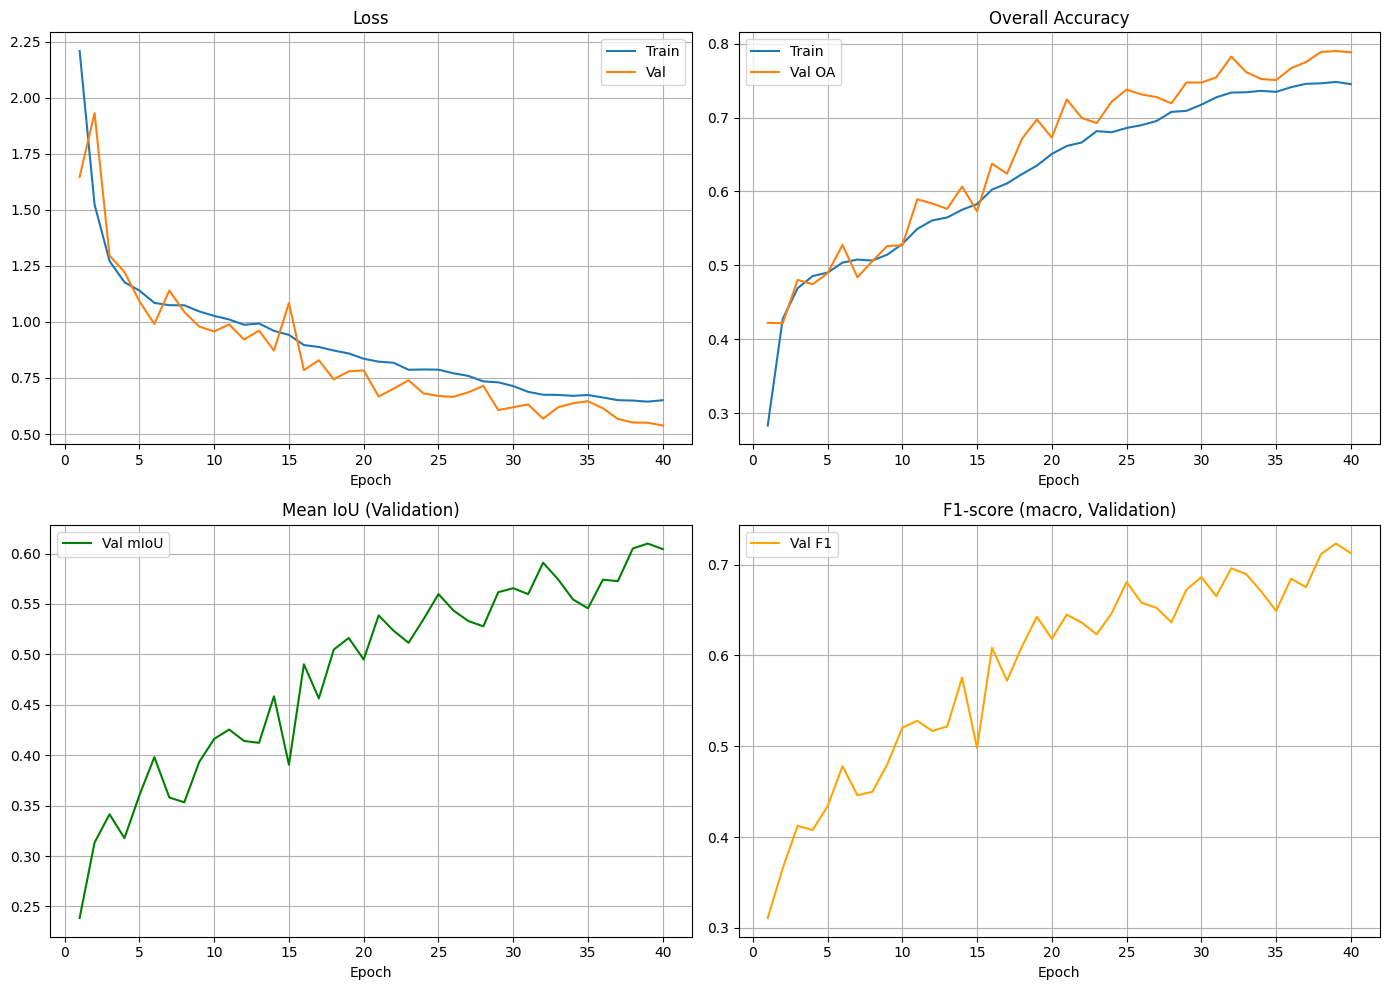

[✔] Training curves saved.

TEST SET EVALUATION (best model)
  Overall Accuracy : 0.7845
  Mean IoU         : 0.6031
  F1 (macro)       : 0.7145
      Class 0 : IoU=0.9705  F1=0.9850
      Class 1 : IoU=0.8285  F1=0.9062
      Class 2 : IoU=0.7443  F1=0.8534
      Class 3 : IoU=0.8771  F1=0.9345
      Class 4 : IoU=0.8391  F1=0.9125
      Class 5 : IoU=0.7565  F1=0.8613
      Class 6 : IoU=0.7788  F1=0.8756
      Class 7 : IoU=0.2073  F1=0.3434
      Class 8 : IoU=0.2527  F1=0.4034
      Class 9 : IoU=0.2734  F1=0.4294
      Class 10 : IoU=0.1712  F1=0.2924
      Class 11 : IoU=0.5855  F1=0.7386
      Class 12 : IoU=0.5646  F1=0.7217
      Class 13 : IoU=0.5937  F1=0.7451
[✔] Test metrics saved.


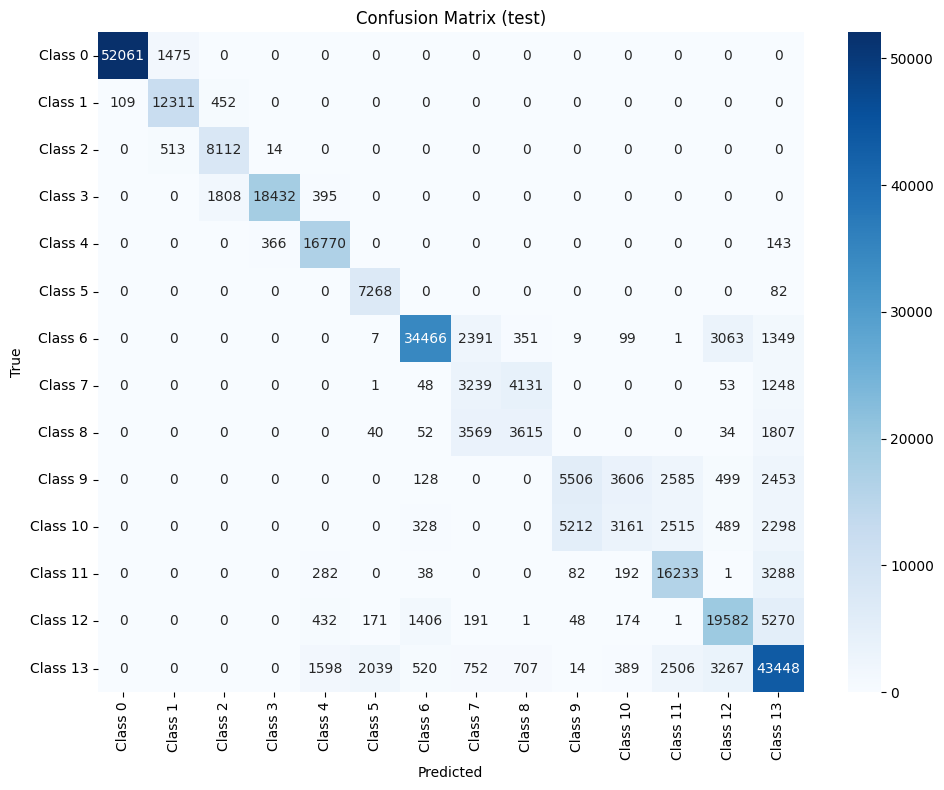

[✔] Confusion matrix (test) saved.


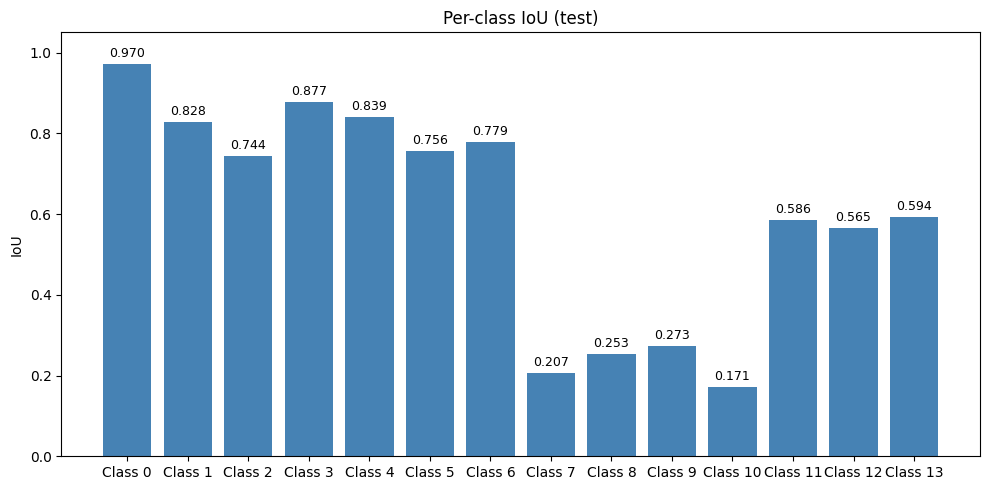

[✔] Per-class IoU chart (test) saved.

INFERENCE: valve_0328_lidar_classes.ply
  Overall Accuracy : 0.8051
  Mean IoU         : 0.6241
  F1 (macro)       : 0.7208
  [✔] Ground truth: /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_4_kpconv/output/holdout_ground_truth.ply
  [✔] Prediction:  /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_4_kpconv/output/holdout_prediction.ply
  [✔] Error map:   /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_4_kpconv/output/holdout_error_map.ply


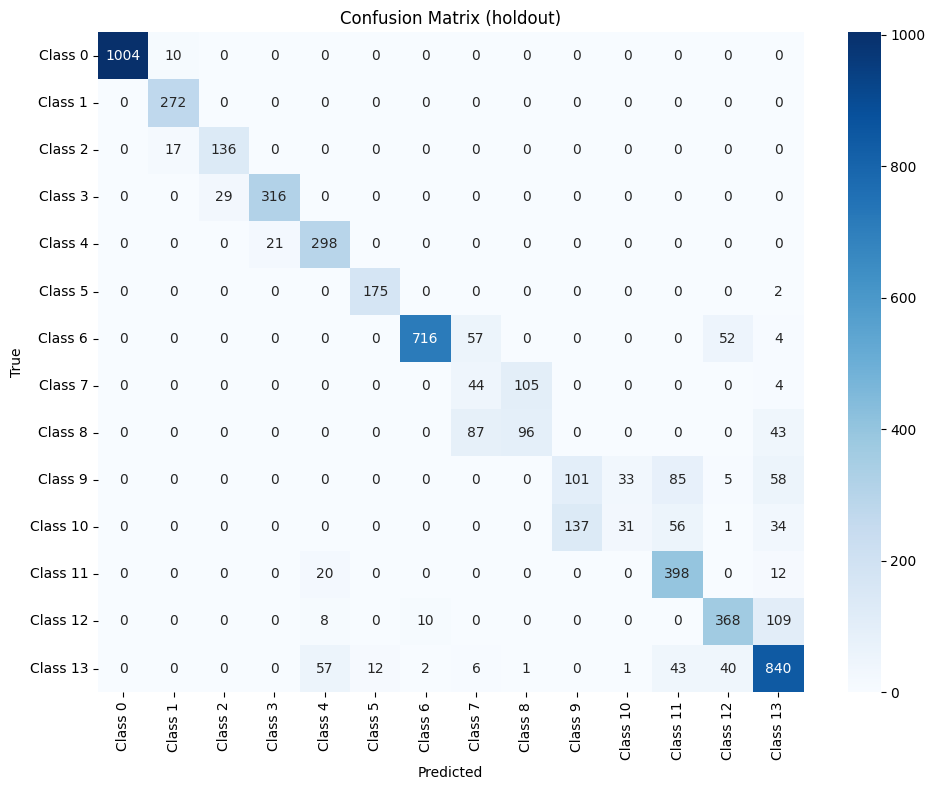

[✔] Confusion matrix (holdout) saved.

ALL DONE  (KPConv)


In [25]:
def main():
    all_files = sorted(glob.glob(os.path.join(CFG["dataset_dir"], "*.ply")))
    assert len(all_files) > 0, f"No .ply files in {CFG['dataset_dir']}"
    print(f"Found {len(all_files)} PLY files.")

    random.shuffle(all_files)
    holdout_file = all_files.pop()
    print(f"[!] Held-out file: {os.path.basename(holdout_file)}")

    num_classes, classes, ce_weights = investigate_dataset(all_files)

    n = len(all_files)
    n_train = int(n * CFG["train_ratio"])
    n_val = int(n * CFG["val_ratio"])
    train_files = all_files[:n_train]
    val_files = all_files[n_train:n_train + n_val]
    test_files = all_files[n_train + n_val:]
    print(f"Split: train={len(train_files)}, val={len(val_files)}, "
          f"test={len(test_files)}")

    train_ds = PointCloudDataset(train_files, CFG["num_points"], augment=True)
    val_ds = PointCloudDataset(val_files, CFG["num_points"], augment=False)
    test_ds = PointCloudDataset(test_files, CFG["num_points"], augment=False)

    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True, num_workers=CFG["num_workers"],
                              pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"],
                            shuffle=False, num_workers=CFG["num_workers"],
                            pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"],
                             shuffle=False, num_workers=CFG["num_workers"],
                             pin_memory=True)

    model = KPConvSeg(
        num_classes=num_classes,
        num_kernel_points=CFG["num_kernel_points"],
        k=CFG["k"],
        dims=tuple(CFG["dims"]),
        npoints=tuple(CFG["npoints"]),
        dropout=CFG["dropout"],
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
    print(f"KPConv parameters: {total_params:,}")

    weight_tensor = torch.tensor(ce_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"],
                                 weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=CFG["scheduler_step"],
        gamma=CFG["scheduler_gamma"])

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_oa": [], "val_miou": [], "val_f1": [],
    }
    best_miou = 0.0
    best_epoch = 0

    print("\n" + "=" * 70)
    print("TRAINING START  (KPConv)")
    print("=" * 70)

    for epoch in range(1, CFG["epochs"] + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE)
        val_metrics = evaluate(
            model, val_loader, criterion, DEVICE, num_classes)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_oa"].append(val_metrics["oa"])
        history["val_miou"].append(val_metrics["miou"])
        history["val_f1"].append(val_metrics["f1_macro"])

        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]["lr"]

        print(f"Epoch {epoch:3d}/{CFG['epochs']}  "
              f"lr={lr_now:.6f}  "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
              f"val_loss={val_metrics['loss']:.4f}  "
              f"val_OA={val_metrics['oa']:.4f}  "
              f"val_mIoU={val_metrics['miou']:.4f}  "
              f"val_F1={val_metrics['f1_macro']:.4f}  "
              f"({elapsed:.1f}s)")

        if val_metrics["miou"] > best_miou:
            best_miou = val_metrics["miou"]
            best_epoch = epoch
            torch.save(model.state_dict(),
                       os.path.join(CFG["output_dir"], "best_model.pth"))
            print(f"  ► New best mIoU: {best_miou:.4f} — model saved.")

    print(f"\nBest val mIoU: {best_miou:.4f} at epoch {best_epoch}")
    torch.save(model.state_dict(),
               os.path.join(CFG["output_dir"], "last_model.pth"))

    plot_training_curves(history, CFG["output_dir"])

    # ── Test Evaluation ───────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("TEST SET EVALUATION (best model)")
    print("=" * 70)

    model.load_state_dict(torch.load(
        os.path.join(CFG["output_dir"], "best_model.pth"),
        map_location=DEVICE))
    test_metrics = evaluate(model, test_loader, criterion, DEVICE, num_classes)

    print(f"  Overall Accuracy : {test_metrics['oa']:.4f}")
    print(f"  Mean IoU         : {test_metrics['miou']:.4f}")
    print(f"  F1 (macro)       : {test_metrics['f1_macro']:.4f}")
    for c in range(num_classes):
        print(f"      Class {classes[c]} : "
              f"IoU={test_metrics['per_class_iou'][c]:.4f}  "
              f"F1={test_metrics['f1_per_class'][c]:.4f}")

    metrics_save = {
        "overall_accuracy": float(test_metrics["oa"]),
        "mean_iou": float(test_metrics["miou"]),
        "f1_macro": float(test_metrics["f1_macro"]),
        "per_class_iou": {str(classes[c]):
                          float(test_metrics["per_class_iou"][c])
                          for c in range(num_classes)},
        "per_class_f1": {str(classes[c]):
                         float(test_metrics["f1_per_class"][c])
                         for c in range(num_classes)},
        "best_epoch": best_epoch,
    }
    with open(os.path.join(CFG["output_dir"], "test_metrics.json"), "w") as f:
        json.dump(metrics_save, f, indent=2)
    print("[✔] Test metrics saved.")

    plot_confusion_matrix(test_metrics["confusion_matrix"], classes,
                          CFG["output_dir"], tag="test")
    plot_per_class_iou(test_metrics["per_class_iou"], classes,
                       CFG["output_dir"], tag="test")

    # ── Inference on held-out ─────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print(f"INFERENCE: {os.path.basename(holdout_file)}")
    print("=" * 70)

    pts_ho, lbl_ho, pred_ho = infer_full_cloud(
        model, holdout_file, DEVICE, num_classes, CFG["num_points"])

    ho_metrics = compute_metrics(pred_ho, lbl_ho, num_classes)
    print(f"  Overall Accuracy : {ho_metrics['oa']:.4f}")
    print(f"  Mean IoU         : {ho_metrics['miou']:.4f}")
    print(f"  F1 (macro)       : {ho_metrics['f1_macro']:.4f}")

    gt_path = os.path.join(CFG["output_dir"], "holdout_ground_truth.ply")
    save_coloured_ply(gt_path, pts_ho, lbl_ho, CLASS_COLORS)
    print(f"  [✔] Ground truth: {gt_path}")

    pred_path = os.path.join(CFG["output_dir"], "holdout_prediction.ply")
    save_coloured_ply(pred_path, pts_ho, pred_ho, CLASS_COLORS)
    print(f"  [✔] Prediction:  {pred_path}")

    # Error map
    error_colors = np.zeros((len(pts_ho), 3), dtype=np.uint8)
    correct = (pred_ho == lbl_ho)
    error_colors[correct] = [0, 200, 0]
    error_colors[~correct] = [255, 0, 0]
    err_path = os.path.join(CFG["output_dir"], "holdout_error_map.ply")
    N_ho = len(pts_ho)
    with open(err_path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {N_ho}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\n"
                "property uchar blue\n")
        f.write("end_header\n")
        for i in range(N_ho):
            f.write(f"{pts_ho[i,0]:.6f} {pts_ho[i,1]:.6f} "
                    f"{pts_ho[i,2]:.6f} "
                    f"{error_colors[i,0]} {error_colors[i,1]} "
                    f"{error_colors[i,2]}\n")
    print(f"  [✔] Error map:   {err_path}")

    plot_confusion_matrix(ho_metrics["confusion_matrix"], classes,
                          CFG["output_dir"], tag="holdout")

    with open(os.path.join(CFG["output_dir"],
                           "training_history.json"), "w") as f:
        json.dump(history, f, indent=2)

    print("\n" + "=" * 70)
    print("ALL DONE  (KPConv)")
    print("=" * 70)


if __name__ == "__main__":
    main()
